In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle

In [2]:
# Dataset Class
class MVTecLOCODataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        
        # Define the path for the images based on the split
        if self.split == "train":
            self.image_dir = os.path.join(self.root_dir, "train", "good")
        elif self.split == "test":
            self.image_dir = os.path.join(self.root_dir, "test", "good_logical_struct_images")
        elif self.split == "test2":
            self.image_dir = os.path.join(self.root_dir, "test", "illogical_with_paint")
        elif self.split == "test3":
            self.image_dir = os.path.join(self.root_dir, "test", "good_logical_without_paint")

        else:
            raise ValueError("Split must be either 'train', 'test', or 'test2'")
        
        # List all image files in the directory
        self.image_files = [f for f in os.listdir(self.image_dir) if f.endswith(".png")]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        # Load the image
        img_name = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_name).convert("RGB")  # Assuming 3-channel images

        if self.transform:
            image = self.transform(image)

        return image

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
import math

class SelfAttention(nn.Module):
    def __init__(self, n_heads, d_embed, in_proj_bias=True, out_proj_bias=True):
        super().__init__()
        # This combines the Wq, Wk and Wv matrices into one matrix
        self.in_proj = nn.Linear(d_embed, 3 * d_embed, bias=in_proj_bias)
        # This one represents the Wo matrix
        self.out_proj = nn.Linear(d_embed, d_embed, bias=out_proj_bias)
        self.n_heads = n_heads
        self.d_head = d_embed // n_heads

    def forward(self, x, causal_mask=False):
        # x: # (Batch_Size, Seq_Len, Dim)

        # (Batch_Size, Seq_Len, Dim)
        input_shape = x.shape 
        
        # (Batch_Size, Seq_Len, Dim)
        batch_size, sequence_length, d_embed = input_shape 

        # (Batch_Size, Seq_Len, H, Dim / H)
        interim_shape = (batch_size, sequence_length, self.n_heads, self.d_head) 

        # (Batch_Size, Seq_Len, Dim) -> (Batch_Size, Seq_Len, Dim * 3) -> 3 tensor of shape (Batch_Size, Seq_Len, Dim)
        q, k, v = self.in_proj(x).chunk(3, dim=-1)
        
        # (Batch_Size, Seq_Len, Dim) -> (Batch_Size, Seq_Len, H, Dim / H) -> (Batch_Size, H, Seq_Len, Dim / H)
        q = q.view(interim_shape).transpose(1, 2)
        k = k.view(interim_shape).transpose(1, 2)
        v = v.view(interim_shape).transpose(1, 2)

        # (Batch_Size, H, Seq_Len, Dim / H) @ (Batch_Size, H, Dim / H, Seq_Len) -> (Batch_Size, H, Seq_Len, Seq_Len)
        weight = q @ k.transpose(-1, -2)
        
        if causal_mask:
            # Mask where the upper triangle (above the principal diagonal) is 1
            mask = torch.ones_like(weight, dtype=torch.bool).triu(1) 
            # Fill the upper triangle with -inf
            weight.masked_fill_(mask, -torch.inf) 
        
        # Divide by d_k (Dim / H). 
        # (Batch_Size, H, Seq_Len, Seq_Len) -> (Batch_Size, H, Seq_Len, Seq_Len)
        weight /= math.sqrt(self.d_head) 

        # (Batch_Size, H, Seq_Len, Seq_Len) -> (Batch_Size, H, Seq_Len, Seq_Len)
        weight = F.softmax(weight, dim=-1) 

        # (Batch_Size, H, Seq_Len, Seq_Len) @ (Batch_Size, H, Seq_Len, Dim / H) -> (Batch_Size, H, Seq_Len, Dim / H)
        output = weight @ v

        # (Batch_Size, H, Seq_Len, Dim / H) -> (Batch_Size, Seq_Len, H, Dim / H)
        output = output.transpose(1, 2) 

        # (Batch_Size, Seq_Len, H, Dim / H) -> (Batch_Size, Seq_Len, Dim)
        output = output.reshape(input_shape) 

        # (Batch_Size, Seq_Len, Dim) -> (Batch_Size, Seq_Len, Dim)
        output = self.out_proj(output) 
        
        # (Batch_Size, Seq_Len, Dim)
        return output

class CrossAttention(nn.Module):
    def __init__(self, n_heads, d_embed, d_cross, in_proj_bias=True, out_proj_bias=True):
        super().__init__()
        self.q_proj   = nn.Linear(d_embed, d_embed, bias=in_proj_bias)
        self.k_proj   = nn.Linear(d_cross, d_embed, bias=in_proj_bias)
        self.v_proj   = nn.Linear(d_cross, d_embed, bias=in_proj_bias)
        self.out_proj = nn.Linear(d_embed, d_embed, bias=out_proj_bias)
        self.n_heads = n_heads
        self.d_head = d_embed // n_heads
    
    def forward(self, x, y):
        # x (latent): # (Batch_Size, Seq_Len_Q, Dim_Q)
        # y (context): # (Batch_Size, Seq_Len_KV, Dim_KV) = (Batch_Size, 77, 768)

        input_shape = x.shape
        batch_size, sequence_length, d_embed = input_shape
        # Divide each embedding of Q into multiple heads such that d_heads * n_heads = Dim_Q
        interim_shape = (batch_size, -1, self.n_heads, self.d_head)
        
        # (Batch_Size, Seq_Len_Q, Dim_Q) -> (Batch_Size, Seq_Len_Q, Dim_Q)
        q = self.q_proj(x)
        # (Batch_Size, Seq_Len_KV, Dim_KV) -> (Batch_Size, Seq_Len_KV, Dim_Q)
        k = self.k_proj(y)
        # (Batch_Size, Seq_Len_KV, Dim_KV) -> (Batch_Size, Seq_Len_KV, Dim_Q)
        v = self.v_proj(y)

        # (Batch_Size, Seq_Len_Q, Dim_Q) -> (Batch_Size, Seq_Len_Q, H, Dim_Q / H) -> (Batch_Size, H, Seq_Len_Q, Dim_Q / H)
        q = q.view(interim_shape).transpose(1, 2) 
        # (Batch_Size, Seq_Len_KV, Dim_Q) -> (Batch_Size, Seq_Len_KV, H, Dim_Q / H) -> (Batch_Size, H, Seq_Len_KV, Dim_Q / H)
        k = k.view(interim_shape).transpose(1, 2) 
        # (Batch_Size, Seq_Len_KV, Dim_Q) -> (Batch_Size, Seq_Len_KV, H, Dim_Q / H) -> (Batch_Size, H, Seq_Len_KV, Dim_Q / H)
        v = v.view(interim_shape).transpose(1, 2) 
        
        # (Batch_Size, H, Seq_Len_Q, Dim_Q / H) @ (Batch_Size, H, Dim_Q / H, Seq_Len_KV) -> (Batch_Size, H, Seq_Len_Q, Seq_Len_KV)
        weight = q @ k.transpose(-1, -2)
        
        # (Batch_Size, H, Seq_Len_Q, Seq_Len_KV)
        weight /= math.sqrt(self.d_head)
        
        # (Batch_Size, H, Seq_Len_Q, Seq_Len_KV)
        weight = F.softmax(weight, dim=-1)
        
        # (Batch_Size, H, Seq_Len_Q, Seq_Len_KV) @ (Batch_Size, H, Seq_Len_KV, Dim_Q / H) -> (Batch_Size, H, Seq_Len_Q, Dim_Q / H)
        output = weight @ v
        
        # (Batch_Size, H, Seq_Len_Q, Dim_Q / H) -> (Batch_Size, Seq_Len_Q, H, Dim_Q / H)
        output = output.transpose(1, 2).contiguous()
        
        # (Batch_Size, Seq_Len_Q, H, Dim_Q / H) -> (Batch_Size, Seq_Len_Q, Dim_Q)
        output = output.view(input_shape)
        
        # (Batch_Size, Seq_Len_Q, Dim_Q) -> (Batch_Size, Seq_Len_Q, Dim_Q)
        output = self.out_proj(output)

        # (Batch_Size, Seq_Len_Q, Dim_Q)
        return output

In [4]:
from torch import nn
from torch.nn import functional as F

class VAE_AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.groupnorm = nn.GroupNorm(32, channels)
        self.attention = SelfAttention(1, channels)
    
    def forward(self, x):
        # x: (Batch_Size, Features, Height, Width)

        residue = x 

        # (Batch_Size, Features, Height, Width) -> (Batch_Size, Features, Height, Width)
        x = self.groupnorm(x)

        n, c, h, w = x.shape
        
        # (Batch_Size, Features, Height, Width) -> (Batch_Size, Features, Height * Width)
        x = x.view((n, c, h * w))
        
        # (Batch_Size, Features, Height * Width) -> (Batch_Size, Height * Width, Features). Each pixel becomes a feature of size "Features", the sequence length is "Height * Width".
        x = x.transpose(-1, -2)
        
        # Perform self-attention WITHOUT mask
        # (Batch_Size, Height * Width, Features) -> (Batch_Size, Height * Width, Features)
        x = self.attention(x)
        
        # (Batch_Size, Height * Width, Features) -> (Batch_Size, Features, Height * Width)
        x = x.transpose(-1, -2)
        
        # (Batch_Size, Features, Height * Width) -> (Batch_Size, Features, Height, Width)
        x = x.view((n, c, h, w))
        
        # (Batch_Size, Features, Height, Width) + (Batch_Size, Features, Height, Width) -> (Batch_Size, Features, Height, Width) 
        x += residue

        # (Batch_Size, Features, Height, Width)
        return x 

class VAE_ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.groupnorm_1 = nn.GroupNorm(32, in_channels)
        self.conv_1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.groupnorm_2 = nn.GroupNorm(32, out_channels)
        self.conv_2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        if in_channels == out_channels:
            self.residual_layer = nn.Identity()
        else:
            self.residual_layer = nn.Conv2d(in_channels, out_channels, kernel_size=1, padding=0)
    
    def forward(self, x):
        # x: (Batch_Size, In_Channels, Height, Width)

        residue = x

        # (Batch_Size, In_Channels, Height, Width) -> (Batch_Size, In_Channels, Height, Width)
        x = self.groupnorm_1(x)
        
        # (Batch_Size, In_Channels, Height, Width) -> (Batch_Size, In_Channels, Height, Width)
        x = F.silu(x)
        
        # (Batch_Size, In_Channels, Height, Width) -> (Batch_Size, Out_Channels, Height, Width)
        x = self.conv_1(x)
        
        # (Batch_Size, Out_Channels, Height, Width) -> (Batch_Size, Out_Channels, Height, Width)
        x = self.groupnorm_2(x)
        
        # (Batch_Size, Out_Channels, Height, Width) -> (Batch_Size, Out_Channels, Height, Width)
        x = F.silu(x)
        
        # (Batch_Size, Out_Channels, Height, Width) -> (Batch_Size, Out_Channels, Height, Width)
        x = self.conv_2(x)
        
        # (Batch_Size, Out_Channels, Height, Width) -> (Batch_Size, Out_Channels, Height, Width)
        return x + self.residual_layer(residue)

In [5]:
from torch import nn
from torch.nn import functional as F
#from decoder import VAE_AttentionBlock, VAE_ResidualBlock

class VAE_Encoder(nn.Sequential):
    def __init__(self):
        super().__init__(
            # (Batch_Size, Channel, Height, Width) -> (Batch_Size, 128, Height, Width)
            nn.Conv2d(3, 128, kernel_size=3, padding=1),
            
             # (Batch_Size, 128, Height, Width) -> (Batch_Size, 128, Height, Width)
            VAE_ResidualBlock(128, 128),
            
            # (Batch_Size, 128, Height, Width) -> (Batch_Size, 128, Height, Width)
            VAE_ResidualBlock(128, 128),
            
            # (Batch_Size, 128, Height, Width) -> (Batch_Size, 128, Height / 2, Width / 2)
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=0),
            
            # (Batch_Size, 128, Height / 2, Width / 2) -> (Batch_Size, 256, Height / 2, Width / 2)
            VAE_ResidualBlock(128, 256), 
            
            # (Batch_Size, 256, Height / 2, Width / 2) -> (Batch_Size, 256, Height / 2, Width / 2)
            VAE_ResidualBlock(256, 256), 
            
            # (Batch_Size, 256, Height / 2, Width / 2) -> (Batch_Size, 256, Height / 4, Width / 4)
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=0), 
            
            # (Batch_Size, 256, Height / 4, Width / 4) -> (Batch_Size, 512, Height / 4, Width / 4)
            VAE_ResidualBlock(256, 512), 
            
            # (Batch_Size, 512, Height / 4, Width / 4) -> (Batch_Size, 512, Height / 4, Width / 4)
            VAE_ResidualBlock(512, 512), 
            
            # (Batch_Size, 512, Height / 4, Width / 4) -> (Batch_Size, 512, Height / 8, Width / 8)
            nn.Conv2d(512, 512, kernel_size=3, stride=2, padding=0), 
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            VAE_ResidualBlock(512, 512), 
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            VAE_ResidualBlock(512, 512), 
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            VAE_ResidualBlock(512, 512), 
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            VAE_AttentionBlock(512), 
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            VAE_ResidualBlock(512, 512), 
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            nn.GroupNorm(32, 512), 
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            nn.SiLU(), 

            # Because the padding=1, it means the width and height will increase by 2
            # Out_Height = In_Height + Padding_Top + Padding_Bottom
            # Out_Width = In_Width + Padding_Left + Padding_Right
            # Since padding = 1 means Padding_Top = Padding_Bottom = Padding_Left = Padding_Right = 1,
            # Since the Out_Width = In_Width + 2 (same for Out_Height), it will compensate for the Kernel size of 3
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 8, Height / 8, Width / 8). 
            nn.Conv2d(512, 8, kernel_size=3, padding=1), 

            # (Batch_Size, 8, Height / 8, Width / 8) -> (Batch_Size, 8, Height / 8, Width / 8)
            nn.Conv2d(8, 8, kernel_size=1, padding=0), 
        )

    def forward(self, x):
        # x: (Batch_Size, Channel, Height, Width)
        # noise: (Batch_Size, 4, Height / 8, Width / 8)

        for module in self:

            if getattr(module, 'stride', None) == (2, 2):  # Padding at downsampling should be asymmetric (see #8)
                # Pad: (Padding_Left, Padding_Right, Padding_Top, Padding_Bottom).
                # Pad with zeros on the right and bottom.
                # (Batch_Size, Channel, Height, Width) -> (Batch_Size, Channel, Height + Padding_Top + Padding_Bottom, Width + Padding_Left + Padding_Right) = (Batch_Size, Channel, Height + 1, Width + 1)
                x = F.pad(x, (0, 1, 0, 1))
            
            x = module(x)
        x *= 0.18215
        
        return x
    
# # Initialize the VAE_Encoder
# encoder = VAE_Encoder()

# # Create a random input tensor with shape (batch_size, channels, height, width)
# # For example, let's test it with a batch of size 4 and images of size 512x512 with 3 channels (RGB)
# input_tensor = torch.rand(4, 3, 512, 512)

# # Pass the input tensor through the encoder
# output = encoder(input_tensor)

# # Print the output shape
# print(f"Output shape: {output.shape}")

In [6]:
class VAE_Decoder(nn.Sequential):
    def __init__(self):
        super().__init__(
            # (Batch_Size, 4, Height / 8, Width / 8) -> (Batch_Size, 4, Height / 8, Width / 8)
            nn.Conv2d(4, 4, kernel_size=1, padding=0),

            # (Batch_Size, 4, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            nn.Conv2d(4, 512, kernel_size=3, padding=1),
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            VAE_ResidualBlock(512, 512), 
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            VAE_AttentionBlock(512), 
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            VAE_ResidualBlock(512, 512), 
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            VAE_ResidualBlock(512, 512), 
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            VAE_ResidualBlock(512, 512), 
            
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 8, Width / 8)
            VAE_ResidualBlock(512, 512), 
            
            # Repeats the rows and columns of the data by scale_factor (like when you resize an image by doubling its size).
            # (Batch_Size, 512, Height / 8, Width / 8) -> (Batch_Size, 512, Height / 4, Width / 4)
            nn.Upsample(scale_factor=2),
            
            # (Batch_Size, 512, Height / 4, Width / 4) -> (Batch_Size, 512, Height / 4, Width / 4)
            nn.Conv2d(512, 512, kernel_size=3, padding=1), 
            
            # (Batch_Size, 512, Height / 4, Width / 4) -> (Batch_Size, 512, Height / 4, Width / 4)
            VAE_ResidualBlock(512, 512), 
            
            # (Batch_Size, 512, Height / 4, Width / 4) -> (Batch_Size, 512, Height / 4, Width / 4)
            VAE_ResidualBlock(512, 512), 
            
            # (Batch_Size, 512, Height / 4, Width / 4) -> (Batch_Size, 512, Height / 4, Width / 4)
            VAE_ResidualBlock(512, 512), 
            
            # (Batch_Size, 512, Height / 4, Width / 4) -> (Batch_Size, 512, Height / 2, Width / 2)
            nn.Upsample(scale_factor=2), 
            
            # (Batch_Size, 512, Height / 2, Width / 2) -> (Batch_Size, 512, Height / 2, Width / 2)
            nn.Conv2d(512, 512, kernel_size=3, padding=1), 
            
            # (Batch_Size, 512, Height / 2, Width / 2) -> (Batch_Size, 256, Height / 2, Width / 2)
            VAE_ResidualBlock(512, 256), 
            
            # (Batch_Size, 256, Height / 2, Width / 2) -> (Batch_Size, 256, Height / 2, Width / 2)
            VAE_ResidualBlock(256, 256), 
            
            # (Batch_Size, 256, Height / 2, Width / 2) -> (Batch_Size, 256, Height / 2, Width / 2)
            VAE_ResidualBlock(256, 256), 
            
            # (Batch_Size, 256, Height / 2, Width / 2) -> (Batch_Size, 256, Height, Width)
            nn.Upsample(scale_factor=2), 
            
            # (Batch_Size, 256, Height, Width) -> (Batch_Size, 256, Height, Width)
            nn.Conv2d(256, 256, kernel_size=3, padding=1), 
            
            # (Batch_Size, 256, Height, Width) -> (Batch_Size, 128, Height, Width)
            VAE_ResidualBlock(256, 128), 
            
            # (Batch_Size, 128, Height, Width) -> (Batch_Size, 128, Height, Width)
            VAE_ResidualBlock(128, 128), 
            
            # (Batch_Size, 128, Height, Width) -> (Batch_Size, 128, Height, Width)
            VAE_ResidualBlock(128, 128), 
            
            # (Batch_Size, 128, Height, Width) -> (Batch_Size, 128, Height, Width)
            nn.GroupNorm(32, 128), 
            
            # (Batch_Size, 128, Height, Width) -> (Batch_Size, 128, Height, Width)
            nn.SiLU(), 
            
            # (Batch_Size, 128, Height, Width) -> (Batch_Size, 3, Height, Width)
            nn.Conv2d(128, 3, kernel_size=3, padding=1), 
        )

    def forward(self, x):
        # x: (Batch_Size, 4, Height / 8, Width / 8)
        
        # Remove the scaling added by the Encoder.
        x /= 0.18215

        for module in self:
            x = module(x)

        # (Batch_Size, 3, Height, Width)
        return x
    
# # Initialize the VAE_Decoder
# decoder = VAE_Decoder()

# # Let's assume the input tensor has a height and width of 512 (the original image size from the encoder).
# # So the output of the encoder should have height and width / 8.
# # Create a random input tensor with shape (batch_size, channels, height/8, width/8)
# batch_size = 4
# input_height, input_width = 512, 512
# encoded_tensor = torch.rand(batch_size, 4, input_height // 8, input_width // 8)

# # Pass the encoded tensor through the decoder
# output = decoder(encoded_tensor)

# # Print the shape of the output
# print(f"Output shape: {output.shape}")

In [7]:
# class Network(nn.Module):
#     def __init__(self):
#         super(Network, self).__init__()
#         self.encoder = VAE_Encoder()
#         self.decoder = VAE_Decoder()

#         self.channel_reduction = nn.Conv2d(8, 4, kernel_size=1)

#     def forward(self, x):
#         z = self.encoder(x)
#         z = self.channel_reduction(z)
#         reconstructed = self.decoder(z)
#         return reconstructed

In [8]:
import torch
import torch.nn as nn

class Network(nn.Module):
    def __init__(self, height=512, width=512):
        super(Network, self).__init__()
        self.encoder = VAE_Encoder()  # Assuming this outputs (Batch_Size, 8, Height / 8, Width / 8)
        self.decoder = VAE_Decoder()  # Assuming this expects (Batch_Size, 4, Height / 8, Width / 8)

        # Channel reduction layer: reduce channels from 8 to 4
        self.channel_reduction = nn.Conv2d(8, 4, kernel_size=1)

        # Fully connected layers
        self.fc1 = nn.Linear(4 * (height // 8) * (width // 8), 512)  # Compress to latent space
        #self.fc1_1 = nn.Linear(512, 512)  # Compress to latent space
        self.fc2 = nn.Linear(512, 4 * (height // 8) * (width // 8))  # Expand back to original flattened shape

    def forward(self, x):
        # Pass through the encoder
        z = self.encoder(x)  # z shape: (Batch_Size, 8, Height / 8, Width / 8)

        # Apply channel reduction: change shape to (Batch_Size, 4, Height / 8, Width / 8)
        z = self.channel_reduction(z)

        # Flatten the output of the encoder for the fully connected layers
        batch_size = z.size(0)
        z = z.view(batch_size, -1)  # Flatten to (Batch_Size, 4 * (Height / 8) * (Width / 8))

        # Apply fully connected layers
        z = self.fc1(z)  # Compress to latent space (Batch_Size, 512)
        #z = self.fc1_1(z)
        z = self.fc2(z)  # Expand back (Batch_Size, 4 * (Height / 8) * (Width / 8))

        # Reshape back to (Batch_Size, 4, Height / 8, Width / 8) for the decoder
        z = z.view(batch_size, 4, x.size(2) // 8, x.size(3) // 8)

        # Pass through the decoder
        reconstructed = self.decoder(z)
        
        return reconstructed

In [9]:
# Training Function
def train(model, train_loader, optimizer, criterion, device):
    model.train()
    
    total_loss = 0
    progress_bar = tqdm(train_loader, desc="Training", unit="batch")

    for images in progress_bar:
        images = images.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        reconstructed = model(images)
        loss = criterion(reconstructed, images)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Accumulate the loss
        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return total_loss / len(train_loader)

In [10]:
# Evaluation Function
def evaluate(model, dataloader, criterion, device, threshold=None):
    model.eval()
    total_loss = 0
    all_scores = []

    with torch.no_grad():
        for images in dataloader:
            images = images.to(device)

            # Forward pass
            reconstructed = model(images)

            # Compute loss
            loss = criterion(reconstructed, images)
            total_loss += loss.item()

            # Compute per-sample reconstruction error (MSE)
            reconstruction_error = nn.functional.mse_loss(reconstructed, images, reduction='none')
            reconstruction_error = reconstruction_error.view(reconstruction_error.size(0), -1)
            reconstruction_error = reconstruction_error.mean(dim=1)

            # Collect reconstruction scores
            all_scores.extend(reconstruction_error.cpu().numpy())

    # Classify as normal or anomalous based on the threshold
    if threshold is not None:
        predictions = [1 if score > threshold else 0 for score in all_scores]
    else:
        predictions = None

    return total_loss / len(dataloader), all_scores, predictions, 

# Visualization Function
def visualize(model, dataloader, device, num_images=4, save_path=None, show_error=True):
    model.eval()
    images = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        reconstructed_image = model(images)

    # Convert to NumPy and transpose dimensions for visualization (batch, height, width, channels)
    images = images.cpu().numpy().transpose(0, 2, 3, 1)
    reconstructed_image = reconstructed_image.cpu().numpy().transpose(0, 2, 3, 1)

    # Rescale images from [-1, 1] to [0, 1]
    images = (images * 0.5) + 0.5
    reconstructed_image = (reconstructed_image * 0.5) + 0.5

    # Clip values to ensure valid image range
    images = np.clip(images, 0, 1)
    reconstructed_image = np.clip(reconstructed_image, 0, 1)

    # Compute reconstruction error if needed
    if show_error:
        reconstruction_error = np.mean((images - reconstructed_image) ** 2, axis=(1, 2, 3))

    # Limit to specified number of images
    n = min(len(images), num_images)
    plt.figure(figsize=(18, 8))
    for i in range(n):
        # Original Image
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images[i])
        ax.axis('off')
        ax.set_title("Original Image")

        # Reconstructed Image
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed_image[i])
        ax.axis('off')
        title = "Reconstructed Image"
        if show_error:
            title += f"\nReconstruction Error: {reconstruction_error[i]:.4f}"
        ax.set_title(title)

    # Save or display the plot
    if save_path:
        plt.savefig(save_path)
        print(f"Visualization saved to {save_path}")
    else:
        plt.show()

    plt.close()

In [11]:
import matplotlib.pyplot as plt

def plot_losses(train_losses, good_test_losses, logical_test_losses, structural_test_losses):
    plt.figure(figsize=(12, 6))

    # Plot Train Losses
    epochs_train = list(train_losses.keys())
    train_values = list(train_losses.values())
    plt.plot(epochs_train, train_values, label="Train Loss", color='blue')

    # Plot Good Test Losses
    epochs_good_test = list(good_test_losses.keys())
    good_test_values = list(good_test_losses.values())
    plt.plot(epochs_good_test, good_test_values, label="Good Test Loss", color='green')

    # Plot Logical Test Losses
    epochs_logical_test = list(logical_test_losses.keys())
    logical_test_values = list(logical_test_losses.values())
    plt.plot(epochs_logical_test, logical_test_values, label="Logical Test Loss", color='red')

    # Plot Structural Test Losses
    epochs_structural_test = list(structural_test_losses.keys())
    structural_test_values = list(structural_test_losses.values())
    plt.plot(epochs_structural_test, structural_test_values, label="Structural Test Loss", color='orange')

    # Adding labels and legends
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train and Test Losses over Epochs")
    plt.legend()

    # Display the plot
    plt.show()


In [12]:
# Checkpoint Save Function
def save_checkpoint(epoch, model, optimizer, checkpoint_path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, checkpoint_path)
    print(f"Checkpoint saved at '{checkpoint_path}'")

# Checkpoint Load Function
def load_checkpoint(checkpoint_path, model, optimizer, device):
    if os.path.isfile(checkpoint_path):
        print(f"Loading checkpoint from '{checkpoint_path}'")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming training from epoch {start_epoch}")
        return start_epoch
    else:
        print(f"No checkpoint found at '{checkpoint_path}'")
        return 0
    
# Save loss dictionaries to a file using pickle
def save_loss_dictionaries(filename, *dicts):
    with open(filename, 'wb') as f:
        pickle.dump(dicts, f)
    print(f"Loss dictionaries saved to {filename}")

# Load loss dictionaries from a file using pickle
def load_loss_dictionaries(filename):
    with open(filename, 'rb') as f:
        return pickle.load(f)

Loading checkpoint from '/home/hafiz/my_thesis/seg_recons/checkpoints/15_onBlackPak_checkpoint_epoch_300.pth'


/tmp/ipykernel_2537012/2932776191.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


Resuming training from epoch 300


Training: 100%|██████████| 161/161 [04:27<00:00,  1.66s/batch, loss=0.00612]


Epoch 302/500, Train Loss: 0.005333, Good IMG Reconstrucion Error: 0.004992, Logical IMG Reconstrucion Error: 0.012303, Structural IMG Reconstruction Error: 0.0230
Good IMGES Test Loss: 0.004924, Logical IMAGES Test Loss: 0.011981, Structural IMAGES Test Loss: 0.023000


Training: 100%|██████████| 161/161 [04:27<00:00,  1.66s/batch, loss=0.00503]


Epoch 304/500, Train Loss: 0.005296, Good IMG Reconstrucion Error: 0.005253, Logical IMG Reconstrucion Error: 0.012322, Structural IMG Reconstruction Error: 0.0239
Good IMGES Test Loss: 0.005244, Logical IMAGES Test Loss: 0.012311, Structural IMAGES Test Loss: 0.023826


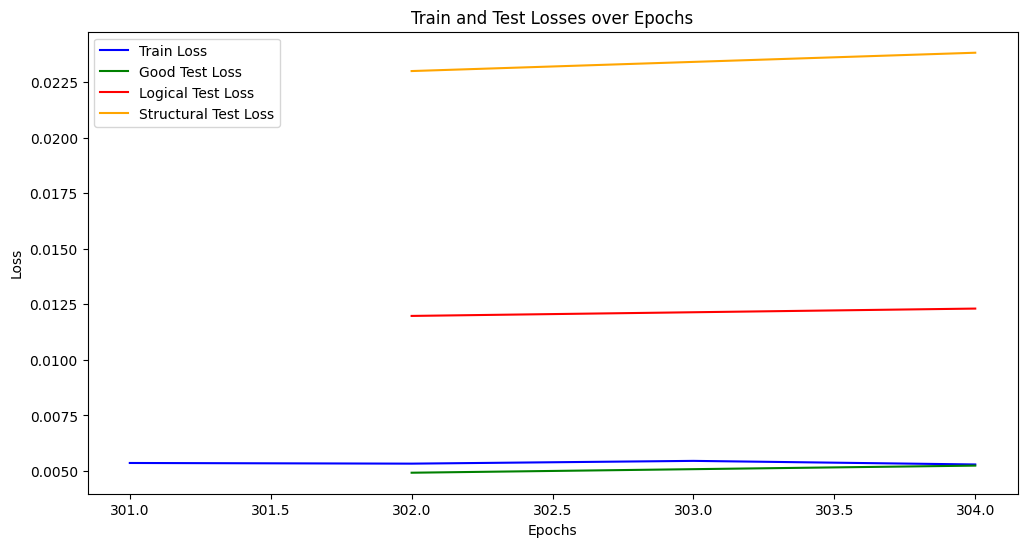

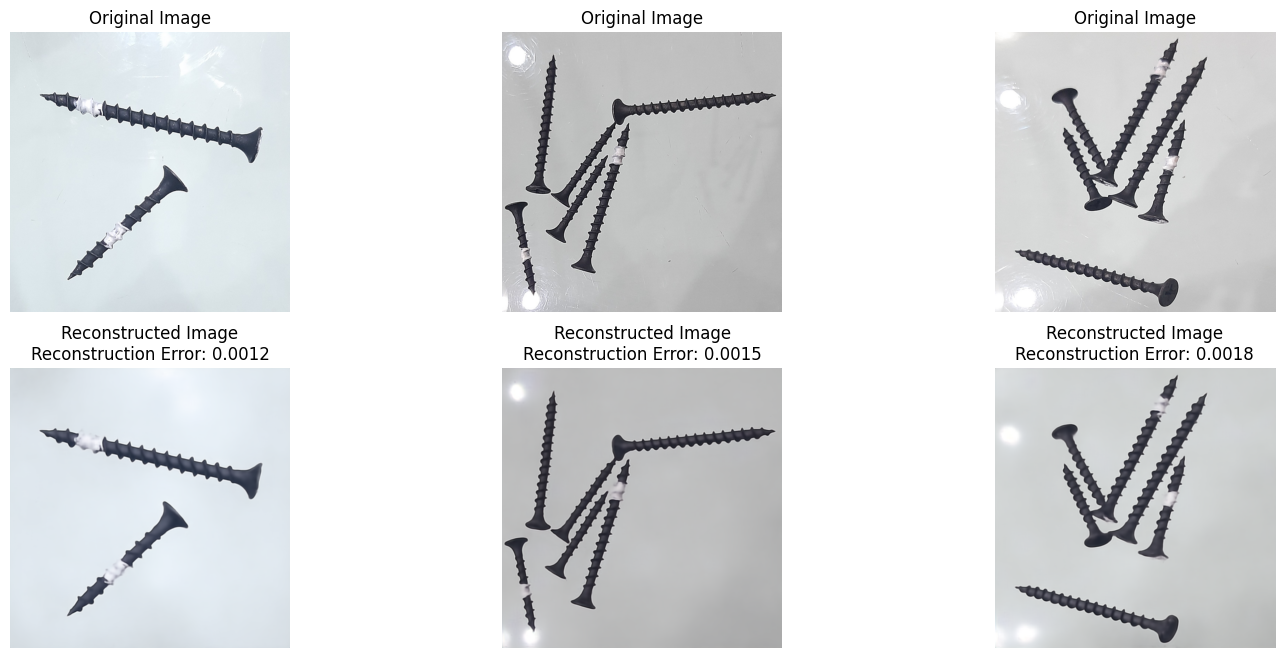

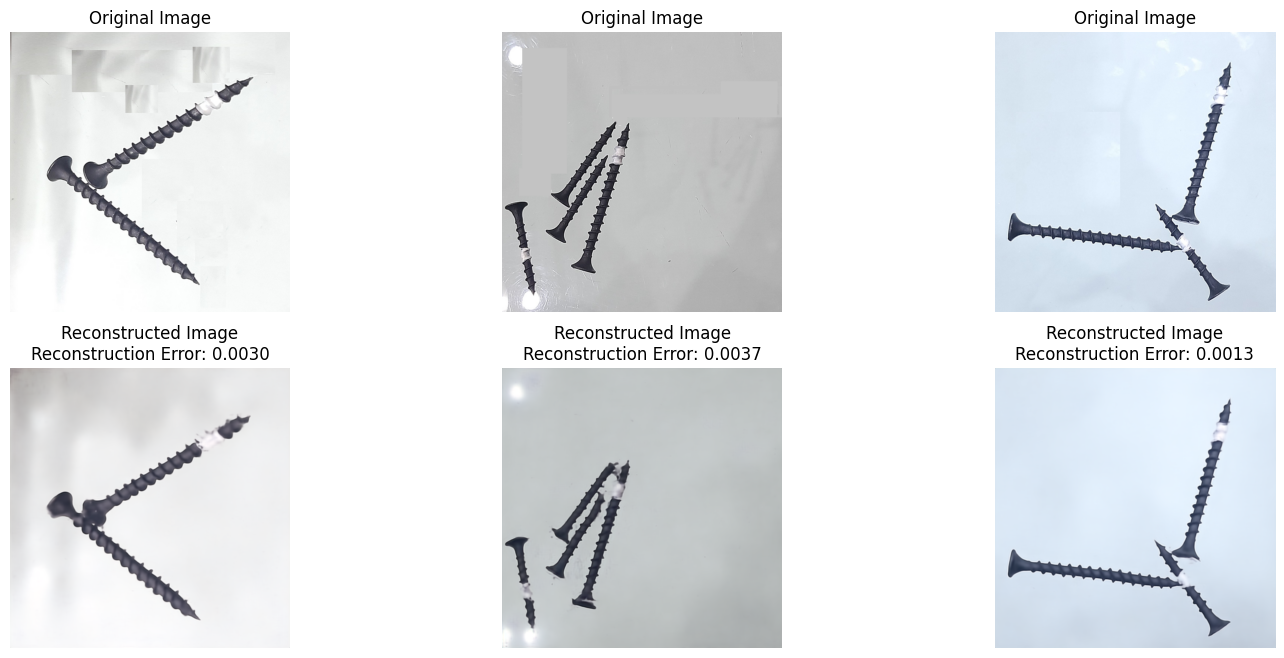

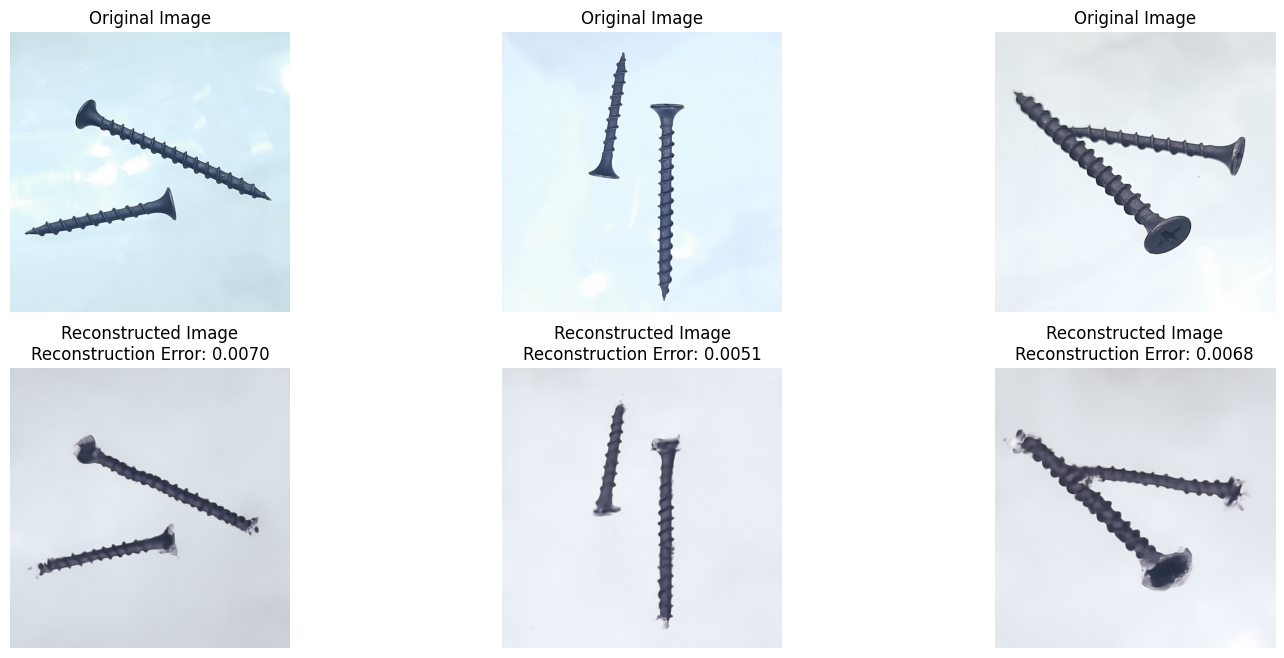

Training: 100%|██████████| 161/161 [04:27<00:00,  1.66s/batch, loss=0.00465]


Epoch 306/500, Train Loss: 0.004714, Good IMG Reconstrucion Error: 0.004281, Logical IMG Reconstrucion Error: 0.011778, Structural IMG Reconstruction Error: 0.0231
Good IMGES Test Loss: 0.004288, Logical IMAGES Test Loss: 0.011578, Structural IMAGES Test Loss: 0.023293


Training: 100%|██████████| 161/161 [04:27<00:00,  1.66s/batch, loss=0.00381]


Epoch 308/500, Train Loss: 0.004207, Good IMG Reconstrucion Error: 0.004094, Logical IMG Reconstrucion Error: 0.011713, Structural IMG Reconstruction Error: 0.0232
Good IMGES Test Loss: 0.004148, Logical IMAGES Test Loss: 0.011529, Structural IMAGES Test Loss: 0.023151


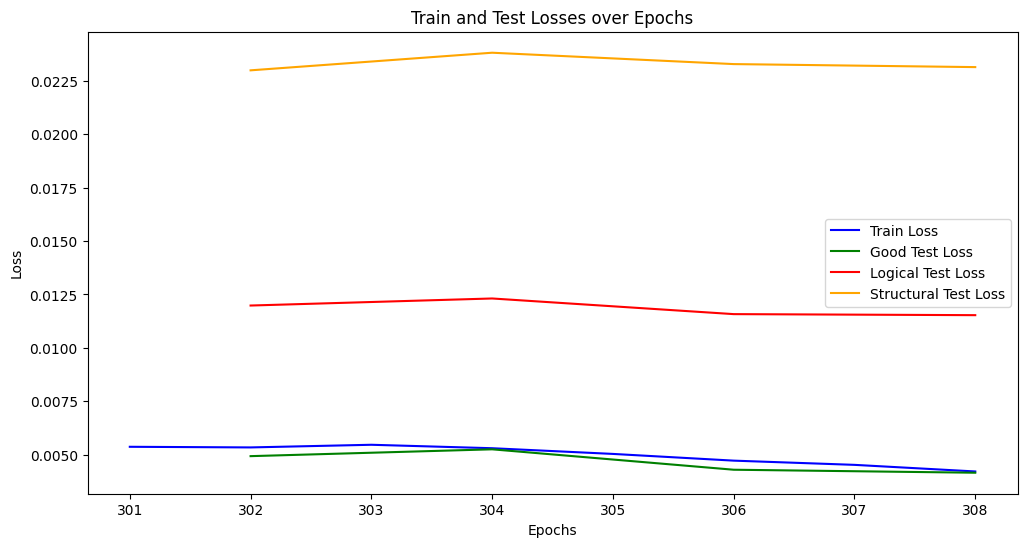

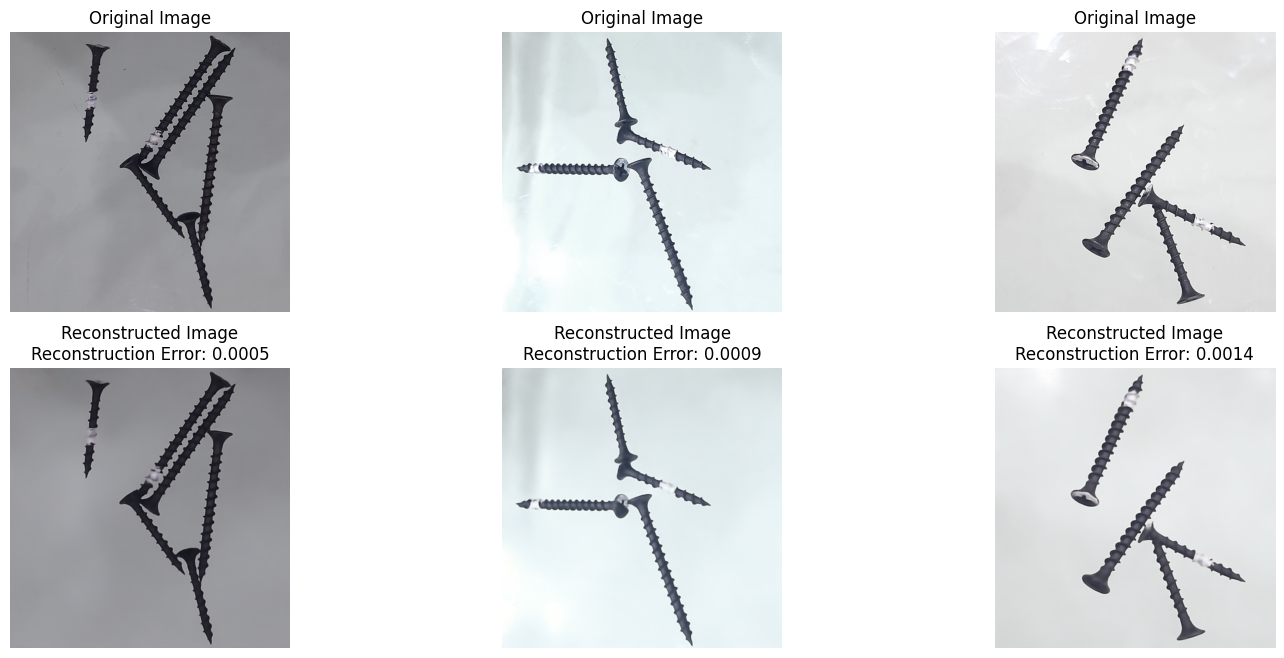

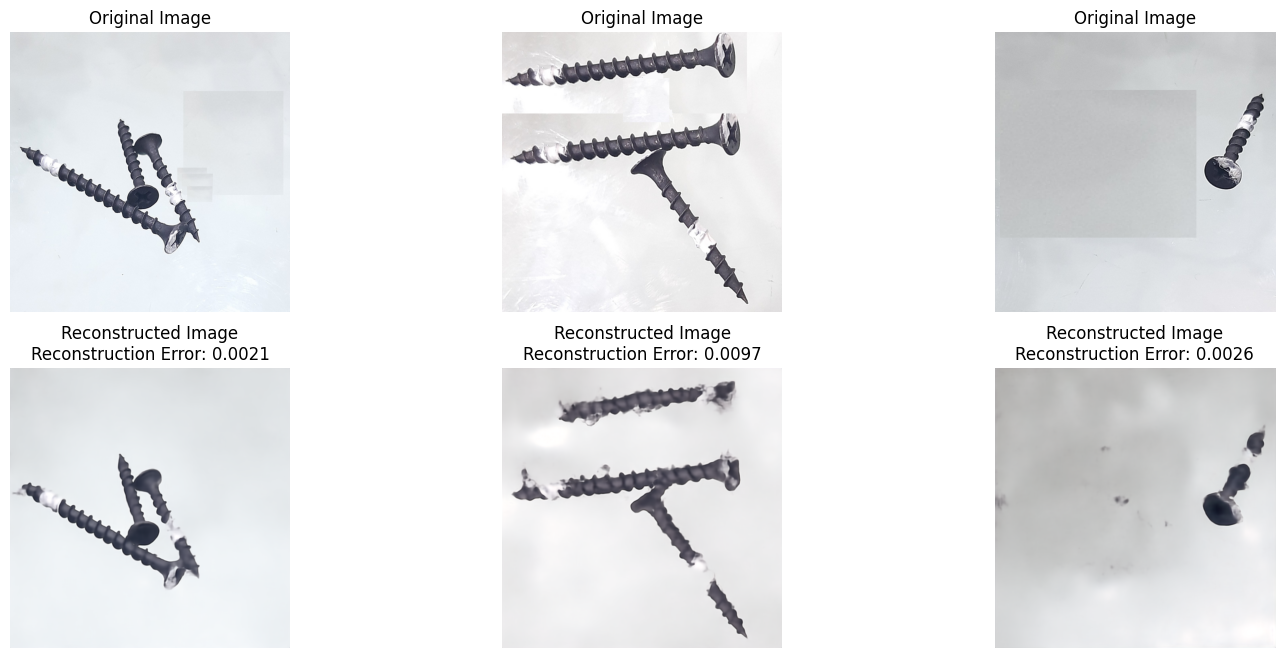

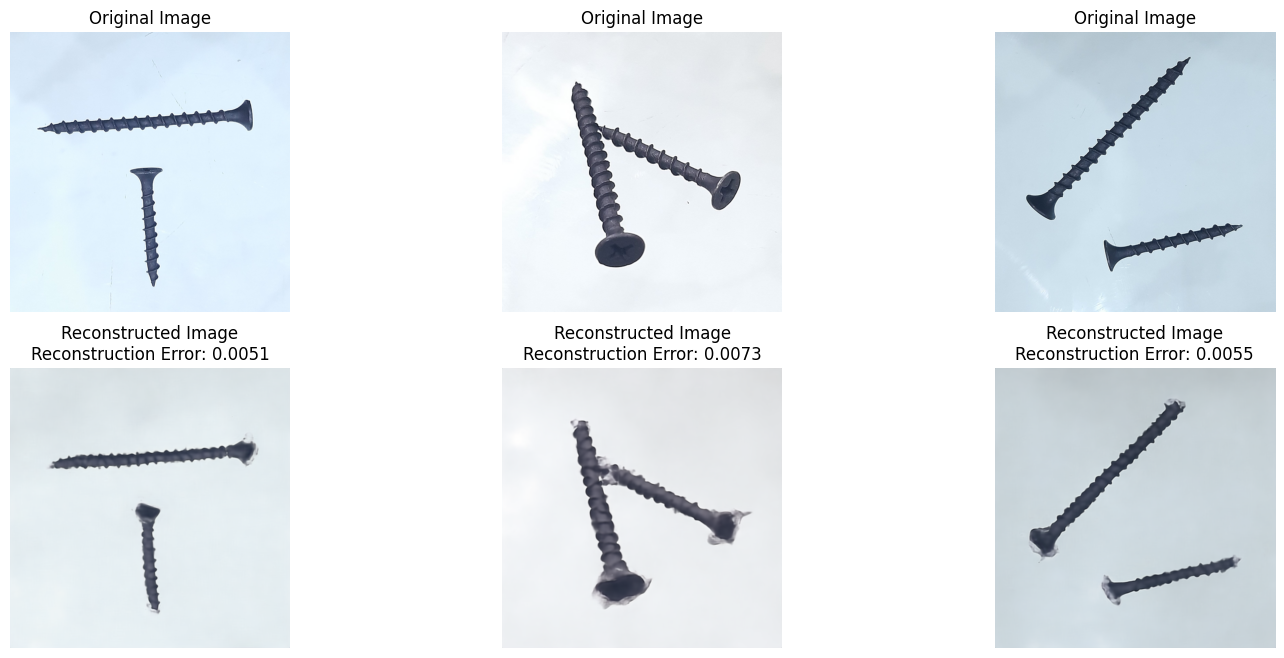

Training: 100%|██████████| 161/161 [04:27<00:00,  1.66s/batch, loss=0.00341]


Epoch 310/500, Train Loss: 0.004267, Good IMG Reconstrucion Error: 0.004408, Logical IMG Reconstrucion Error: 0.011793, Structural IMG Reconstruction Error: 0.0230
Good IMGES Test Loss: 0.004362, Logical IMAGES Test Loss: 0.012875, Structural IMAGES Test Loss: 0.023039


Training: 100%|██████████| 161/161 [04:27<00:00,  1.66s/batch, loss=0.00363]


Epoch 312/500, Train Loss: 0.004017, Good IMG Reconstrucion Error: 0.003702, Logical IMG Reconstrucion Error: 0.011377, Structural IMG Reconstruction Error: 0.0228
Good IMGES Test Loss: 0.003627, Logical IMAGES Test Loss: 0.011582, Structural IMAGES Test Loss: 0.022767


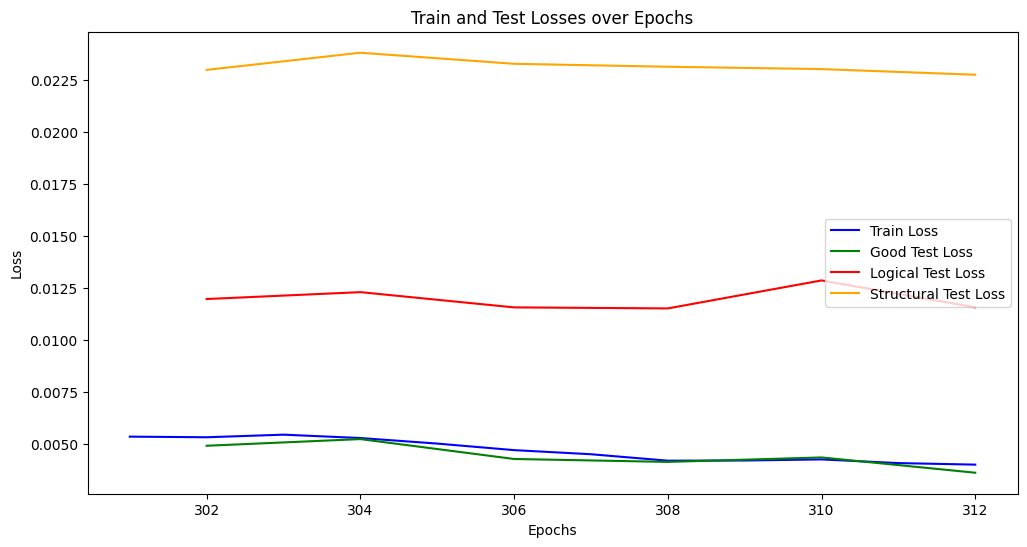

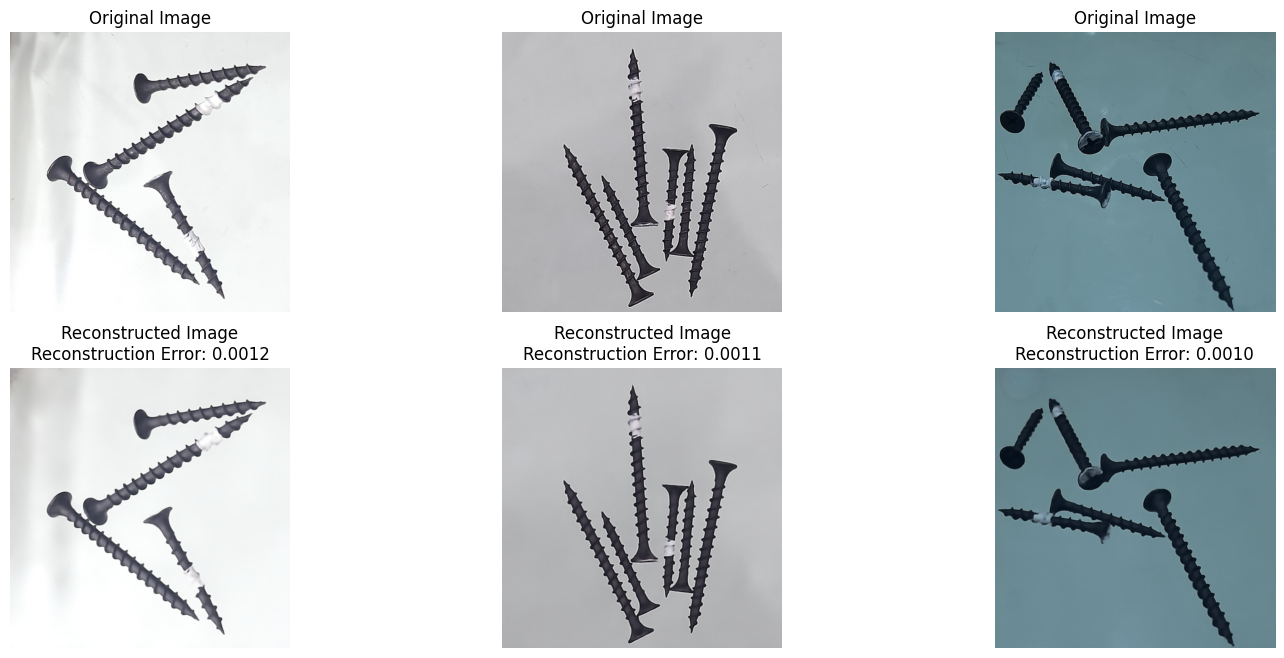

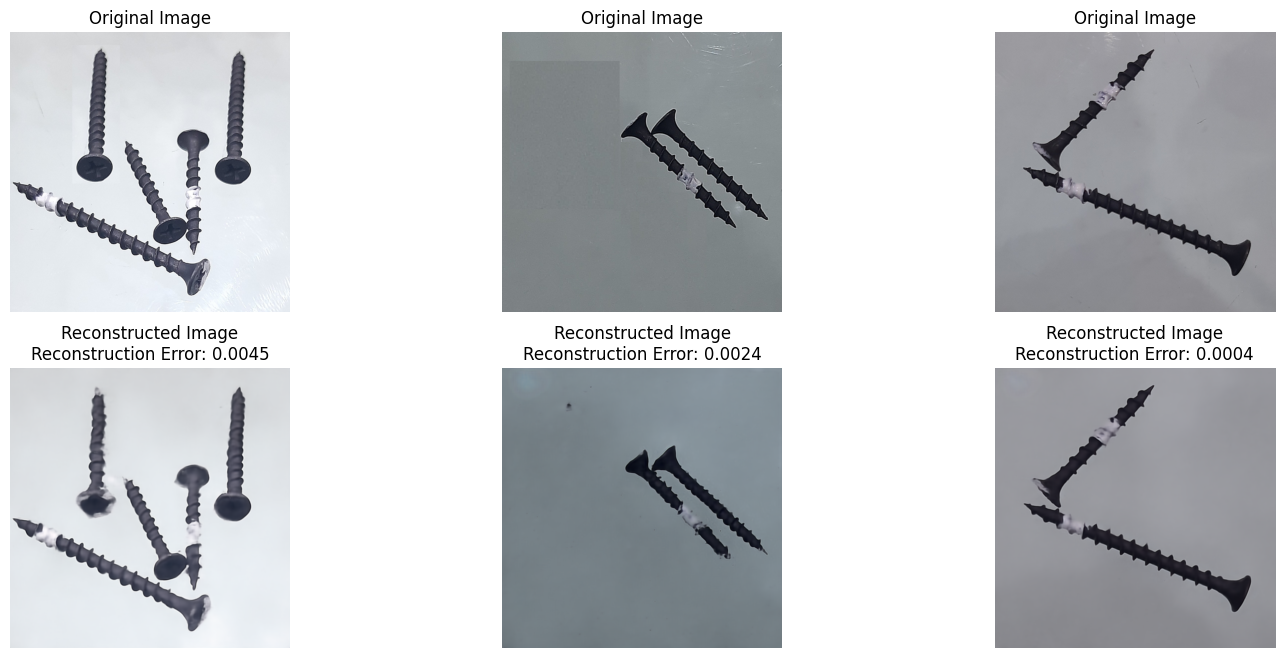

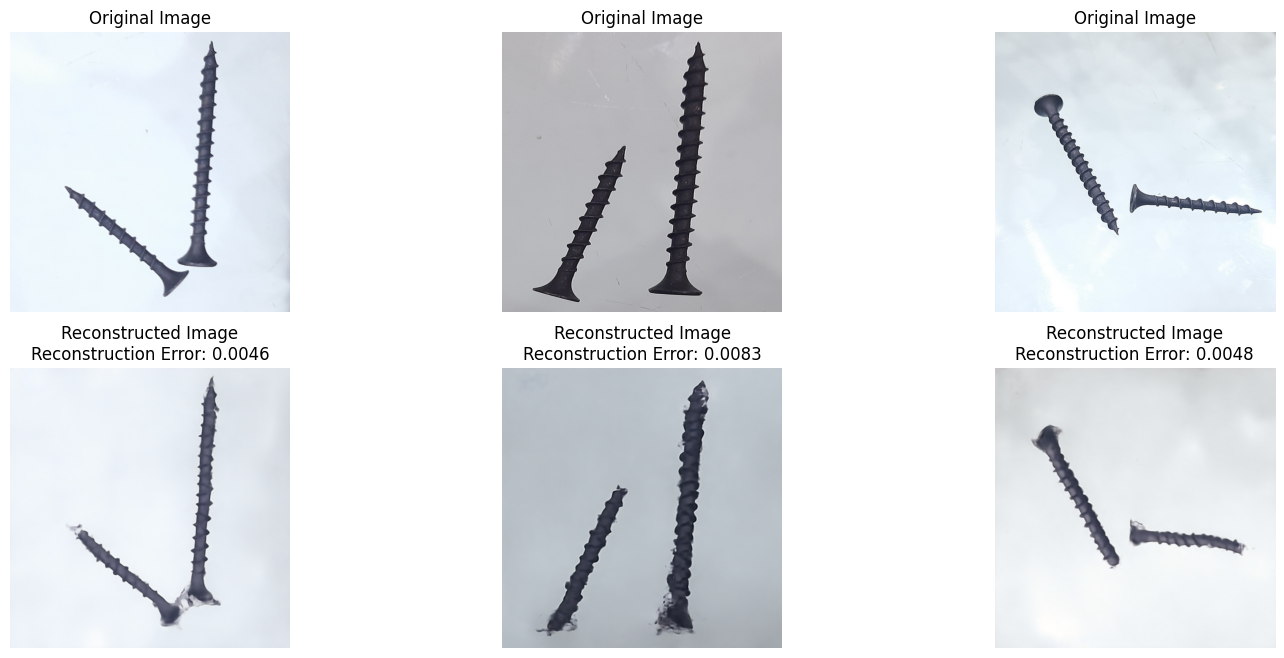

Training:   2%|▏         | 4/161 [00:08<05:25,  2.08s/batch, loss=0.00424]


KeyboardInterrupt: 

In [13]:
# Main Function
def main():
    # Hyperparameters
    img_size = 512  # Adjusted to fit in memory
    num_channels = 3
    batch_size = 3
    num_epochs = 500
    learning_rate = 1e-4
    ROOT_DIR = "/home/hafiz/my_thesis/seg_recons/dataset/black_pak_screws"
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

    # Data Transformations
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        #transforms.RandomHorizontalFlip(),
        #transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5] * num_channels, std=[0.5] * num_channels),
    ])

    # Datasets and Data Loaders
    train_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='train', transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Good images
    test_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='test', transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

    # Logical anomalies images
    test_dataset2 = MVTecLOCODataset(root_dir=ROOT_DIR, split='test2', transform=transform)
    test_loader2 = DataLoader(test_dataset2, batch_size=batch_size, shuffle=True)

    # Structural anomalies images
    test_dataset3 = MVTecLOCODataset(root_dir=ROOT_DIR, split='test3', transform=transform)
    test_loader3 = DataLoader(test_dataset3, batch_size=batch_size, shuffle=True)

    model = Network().to(device)

    # Optimizer and Loss Function
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss(reduction='mean')

    # Load checkpoint if available
    checkpoint_path = '/home/hafiz/my_thesis/seg_recons/checkpoints/15_onBlackPak_checkpoint_epoch_300.pth'
    start_epoch = load_checkpoint(checkpoint_path, model, optimizer, device)

    # Track loss for plotting using dictionaries
    epochs_and_trainlosses = {}
    epochs_and_good_test_losses = {}
    epochs_and_logical_test_losses = {}
    epochs_and_structural_test_losses = {}

    # Training Loop
    for epoch in range(start_epoch, num_epochs):
        # Train
        train_loss = train(model, train_loader, optimizer, criterion, device)
        epochs_and_trainlosses[epoch + 1] = train_loss  # Adding 1 to match epoch number (1-indexed)

        # Evaluate every 2 epochs
        if (epoch + 1) % 2  == 0:
            # Evaluate on good test set
            good_test_loss, good_all_scores, predictions = evaluate(model, test_loader, criterion, device)
            epochs_and_good_test_losses[epoch + 1] = good_test_loss
            good_mean_score = np.mean(good_all_scores) if good_all_scores else 0

            # Evaluate on logical test set
            logical_test_loss, logical_all_scores, predictions = evaluate(model, test_loader2, criterion, device)
            epochs_and_logical_test_losses[epoch + 1] = logical_test_loss
            logical_mean_score = np.mean(logical_all_scores) if logical_all_scores else 0

            # Evaluate on structural test set
            structural_test_loss, structural_all_scores, predictions2 = evaluate(model, test_loader3, criterion, device)
            epochs_and_structural_test_losses[epoch + 1] = structural_test_loss
            structural_mean_score = np.mean(structural_all_scores) if structural_all_scores else 0

            print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss:.6f}, Good IMG Reconstrucion Error: {good_mean_score:.6f}, Logical IMG Reconstrucion Error: {logical_mean_score:.6f}, Structural IMG Reconstruction Error: {structural_mean_score:.4f}")
            print(f"Good IMGES Test Loss: {good_test_loss:.6f}, Logical IMAGES Test Loss: {logical_test_loss:.6f}, Structural IMAGES Test Loss: {structural_test_loss:.6f}")

        # Plot losses every 6 epochs
        if (epoch + 1) % 4 == 0:
            plot_losses(epochs_and_trainlosses, epochs_and_good_test_losses, epochs_and_logical_test_losses, epochs_and_structural_test_losses)

            # Visualize
            visualize(model, test_loader, device, num_images=4)
            visualize(model, test_loader2, device, num_images=4)
            visualize(model, test_loader3, device, num_images=4)

        # Save checkpoint every 25 epochs
        if (epoch + 1) % 25 == 0:
            save_checkpoint(epoch, model, optimizer, f'15_2_onBlackPak_checkpoint_epoch_{epoch + 1}.pth')
            # Save the loss dictionaries for plotting later
            save_loss_dictionaries('15_2_onBlackPak_loss_data.pkl', epochs_and_trainlosses, epochs_and_good_test_losses, epochs_and_logical_test_losses, epochs_and_structural_test_losses)

    # Save final model
    save_checkpoint(num_epochs, model, optimizer, '15_2_onBlackPak_model_final.pth')

    # Save the loss dictionaries for plotting later
    save_loss_dictionaries('15_2_onBlackPak_loss_data.pkl', epochs_and_trainlosses, epochs_and_good_test_losses, epochs_and_logical_test_losses, epochs_and_structural_test_losses)

if __name__ == "__main__":
    main()
